In [2]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [3]:
df1 = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\cluster_F3LILT_051225_oa.h5")
imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_imu_eyecam_dict.npz")

0it [00:00, ?it/s]

gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf


1it [00:21, 21.87s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf


2it [00:35, 16.85s/it]

...

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf


71it [25:32, 36.62s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf


72it [25:43, 21.44s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_gaze_new_criterian_analysis.pdf


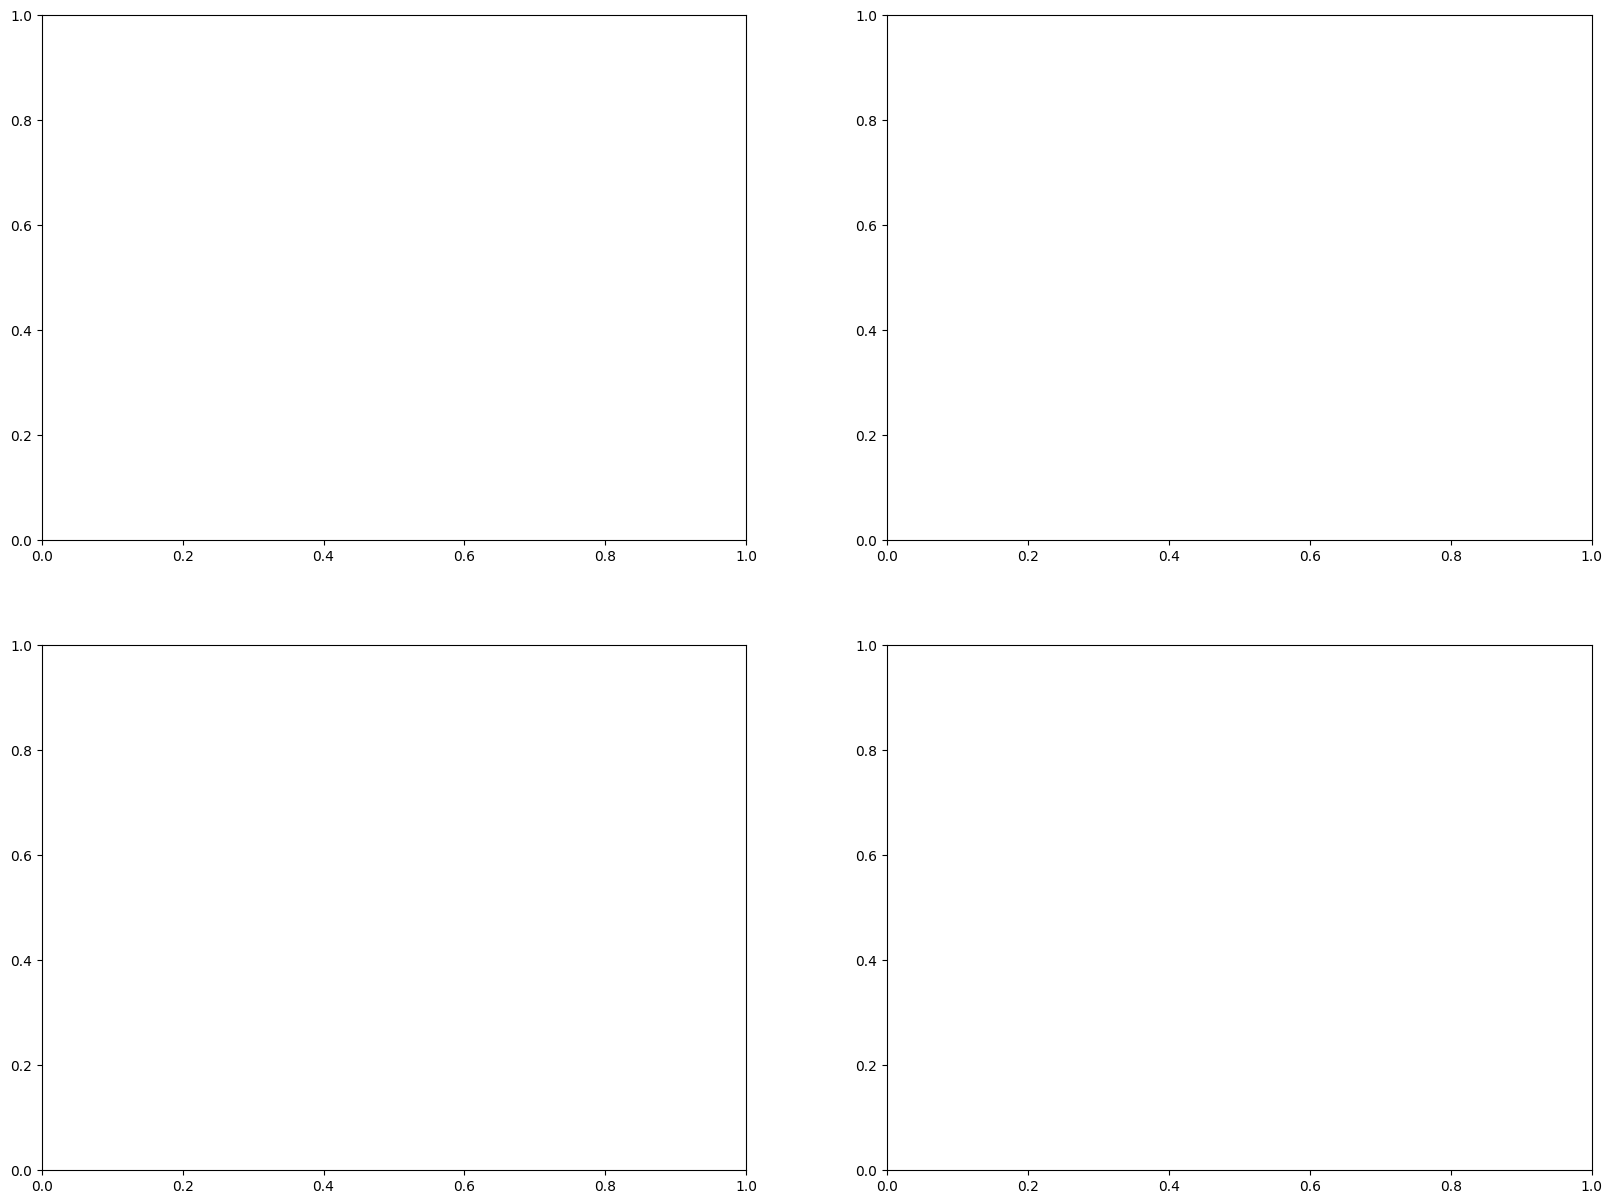

In [4]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
gaze_shift_trials_figures_pdf(
    df =  df1, eyeT=imu['eyeT'], dEye_dps=imu['dEye_dps'],dGaze=imu['dGaze'],dHead=imu['dHead'],gazeR_event=imu['gazeR_event'], gazeL_event=imu['gazeL_event'], OpenephysT0=imu['Openephys_time'][0],output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="051225_F3LILT_gaze_new_criterian_analysis.pdf"  # Average ±2 frames around the target
)

In [ ]:
F3LILT_051325_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\cluster_F3LILT_051225_oa.h5")
F3LILT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_imu_eyecam_dict.npz")
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
gaze_shift_trials_figures_pdf(
    df =  F3LILT_051325_df, eyeT=F3LILT_051325_imu['eyeT'], dEye_dps=F3LILT_051325_imu['dEye_dps'],dGaze=F3LILT_051325_imu['dGaze'],dHead=F3LILT_051325_imu['dHead'],gazeR_event=F3LILT_051325_imu['gazeR_event'], gazeL_event=F3LILT_051325_imu['gazeL_event'], OpenephysT0=F3LILT_051325_imu['Openephys_time'][0],output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="051325_F3LILT_gaze_new_criterian_analysis.pdf"  # Average ±2 frames around the target
)

In [9]:
F3LITT_051225_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\cluster_F3LITT_051225_oa.h5")
F3LITT_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_imu_eyecam_dict.npz")

0it [00:00, ?it/s]

gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf


1it [00:28, 28.88s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf


2it [00:46, 22.46s/it]

...

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf


79it [24:57, 12.74s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf


80it [25:06, 18.83s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_gaze_new_criterian_analysis.pdf


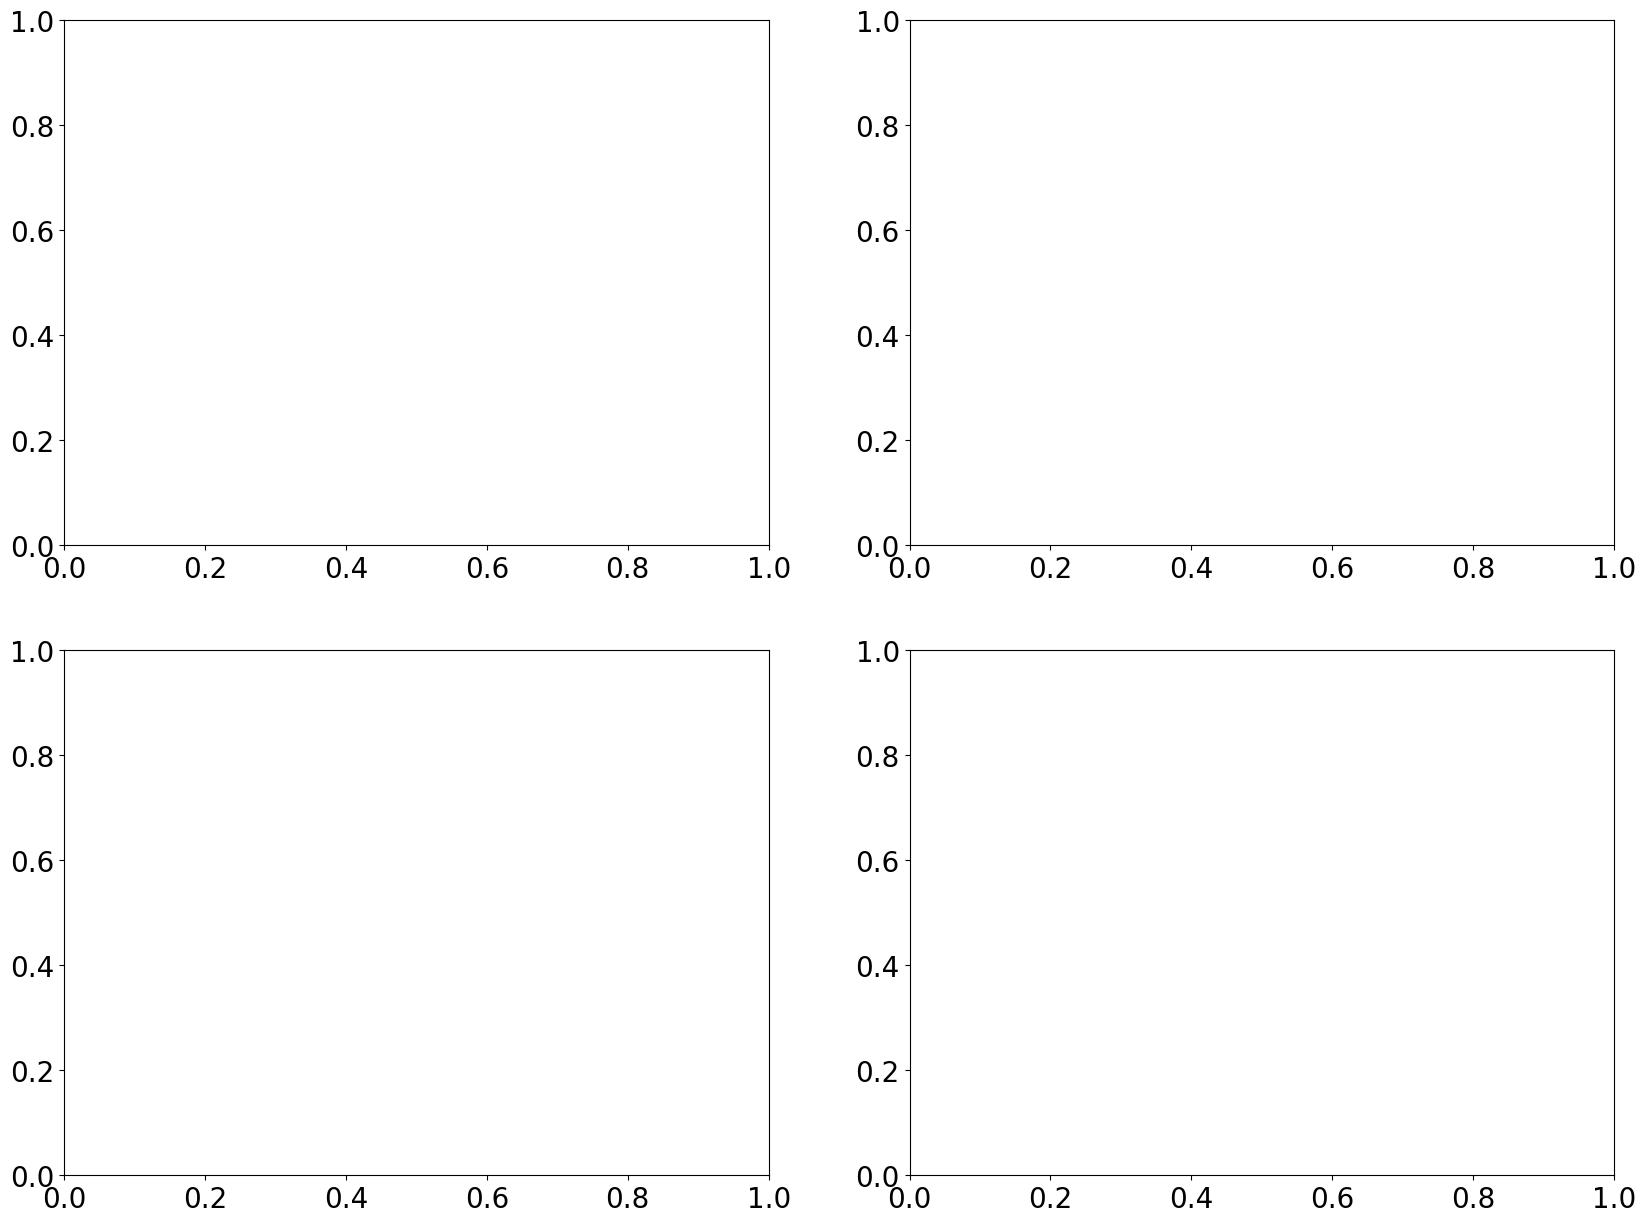

In [10]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
gaze_shift_trials_figures_pdf(
    df =  F3LITT_051225_df, eyeT=F3LITT_051225_imu['eyeT'], dEye_dps=F3LITT_051225_imu['dEye_dps'],dGaze=F3LITT_051225_imu['dGaze'],dHead=F3LITT_051225_imu['dHead'],gazeR_event=F3LITT_051225_imu['gazeR_event'], gazeL_event=F3LITT_051225_imu['gazeL_event'], OpenephysT0=F3LITT_051225_imu['Openephys_time'][0],output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam",
    video_paths=video_paths, output_filename="051225_F3LITT_gaze_new_criterian_analysis.pdf"  # Average ±2 frames around the target
)

In [ ]:
F3LITT_051325_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\cluster_F3LITT_051325_oa.h5")
F3LITT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\051325_F3LITT_imu_eyecam_dict.npz")
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\051325_F3LITT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\051325_F3LITT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\051325_F3LITT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
gaze_shift_trials_figures_pdf(
    df =  df1, eyeT=imu['eyeT'], dEye_dps=imu['dEye_dps'],dGaze=imu['dGaze'],dHead=imu['dHead'],gazeR_event=imu['gazeR_event'], gazeL_event=imu['gazeL_event'], OpenephysT0=imu['Openephys_time'][0],output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam",
    video_paths=video_paths, output_filename="051325_F3LITT_gaze_new_criterian_analysis.pdf"  # Average ±2 frames around the target
)

In [ ]:
F3LILT_051325_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\cluster_F3LILT_051325_oa.h5")
F3LILT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_imu_eyecam_dict.npz")
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
gaze_shift_trials_figures_pdf(
    df =  df1, eyeT=imu['eyeT'], dEye_dps=imu['dEye_dps'],dGaze=imu['dGaze'],dHead=imu['dHead'],gazeR_event=imu['gazeR_event'], gazeL_event=imu['gazeL_event'], OpenephysT0=imu['Openephys_time'][0],output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="051325_F3LILT_gaze_new_criterian_analysis.pdf"  # Average ±2 frames around the target
)

0it [00:00, ?it/s]

gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf


1it [00:29, 29.63s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf


2it [00:44, 20.68s/it]

...

rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf


92it [26:58, 23.69s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf


93it [27:11, 17.54s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_gaze_new_criterian_analysis.pdf


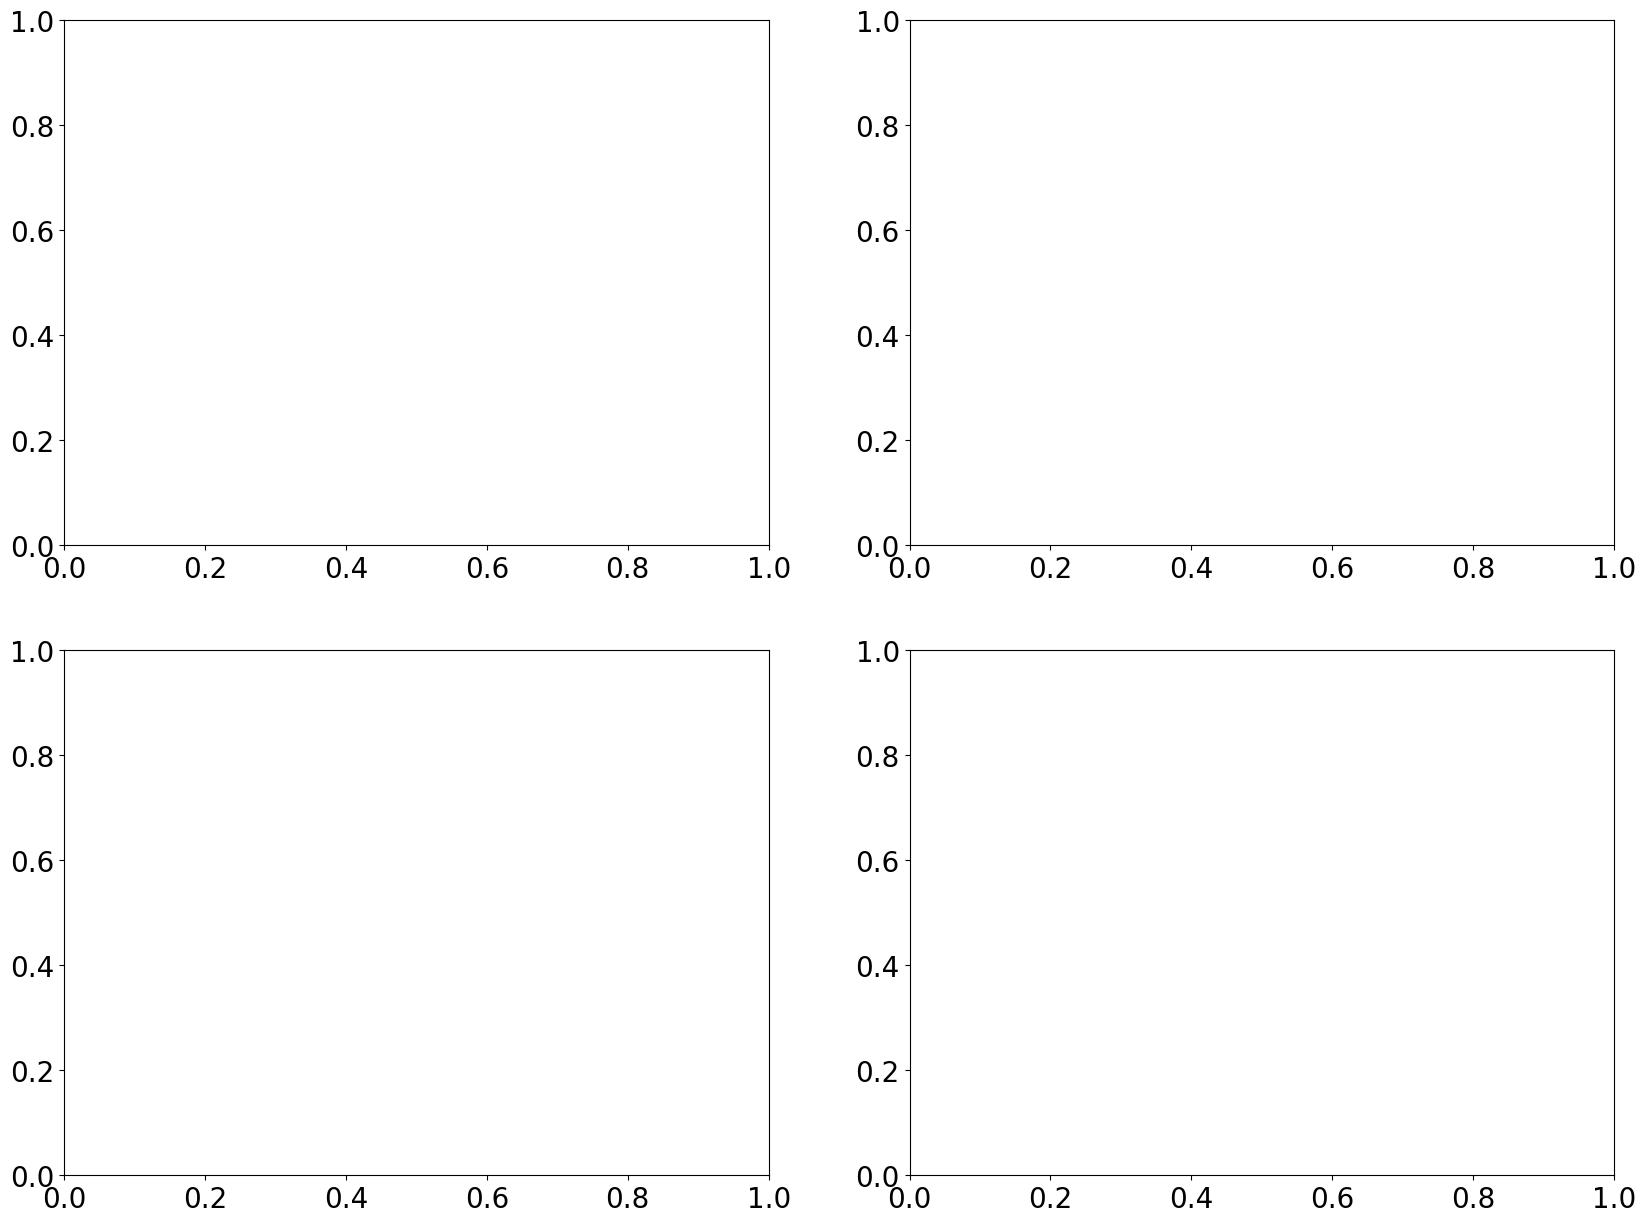

In [16]:
F3LILT_050825_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\cluster_F3LILT_050825_oa.h5")
F3LILT_050825_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_imu_eyecam_dict.npz")
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_control_Rig2_oa_cam1_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_control_Rig2_oa_cam1_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_control_Rig2_oa_cam1_WORLDdeinter.avi"
]
gaze_shift_trials_figures_pdf(
    df =  F3LILT_050825_df, eyeT=F3LILT_050825_imu['eyeT'], dEye_dps=F3LILT_050825_imu['dEye_dps'],dGaze=F3LILT_050825_imu['dGaze'],dHead=F3LILT_050825_imu['dHead'],gazeR_event=F3LILT_050825_imu['gazeR_event'], gazeL_event=F3LILT_050825_imu['gazeL_event'], OpenephysT0=F3LILT_050825_imu['Openephys_time'][0],output_dir=r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1",
    video_paths=video_paths, output_filename="050825_F3LILT_gaze_new_criterian_analysis.pdf"  # Average ±2 frames around the target
)

0it [00:00, ?it/s]

gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf


1it [00:33, 33.66s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf


2it [01:27, 45.59s/it]

...

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf


8it [10:46, 83.71s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf


9it [10:59, 73.26s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_gaze_new_criterian_analysis.pdf


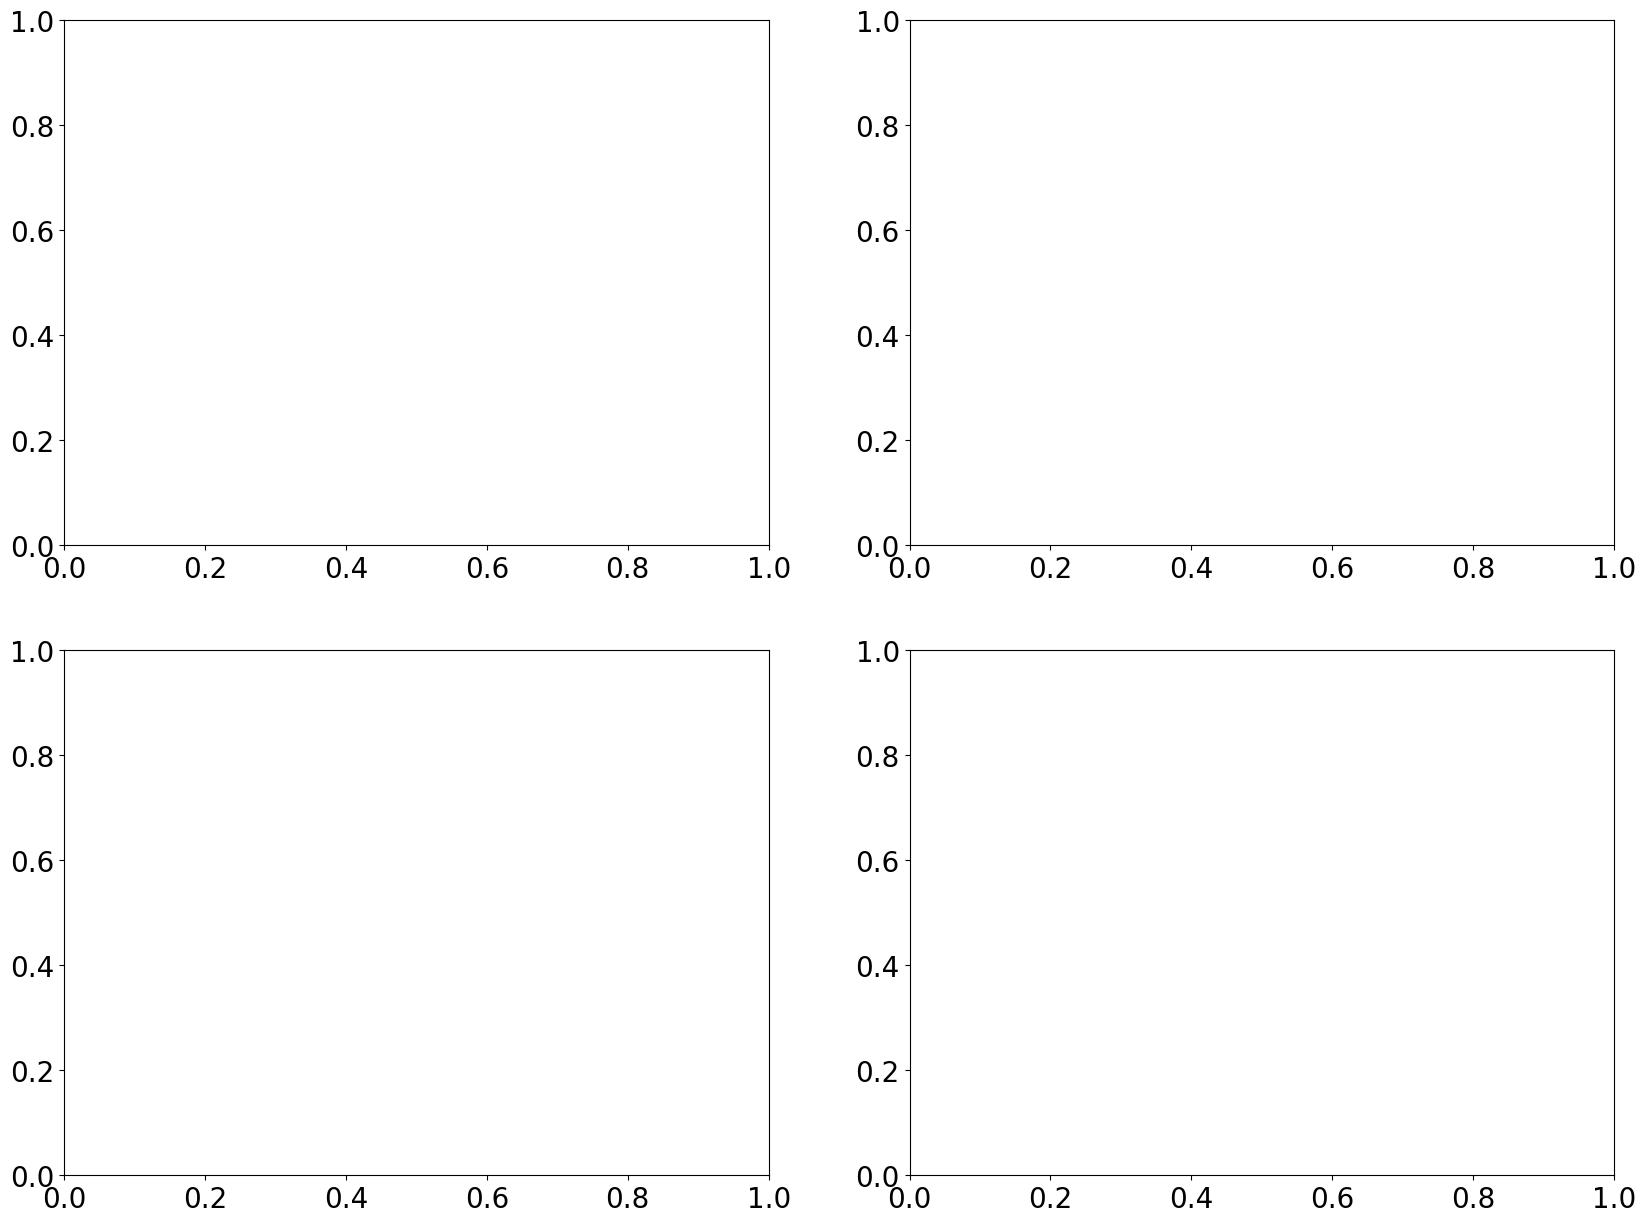

In [17]:
J731_050825_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\cluster_J731_050825_oa.h5")
J731_050825_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_imu_eyecam_dict.npz")
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_control_Rig2_oa_cam1_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_control_Rig2_oa_cam1_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_control_Rig2_oa_cam1_WORLDdeinter.avi"
]
gaze_shift_trials_figures_pdf(
    df =  J731_050825_df, eyeT=J731_050825_imu['eyeT'], dEye_dps=J731_050825_imu['dEye_dps'],dGaze=J731_050825_imu['dGaze'],dHead=J731_050825_imu['dHead'],gazeR_event=J731_050825_imu['gazeR_event'], gazeL_event=J731_050825_imu['gazeL_event'], OpenephysT0=J731_050825_imu['Openephys_time'][0],output_dir=r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1",
    video_paths=video_paths, output_filename="050825_J731_gaze_new_criterian_analysis.pdf"  # Average ±2 frames around the target
)

0it [00:00, ?it/s]

gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf


1it [00:49, 49.95s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf


2it [01:40, 50.15s/it]

...

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf


116it [55:08, 14.35s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf


117it [55:28, 28.45s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_gaze_new_criterian_analysis.pdf


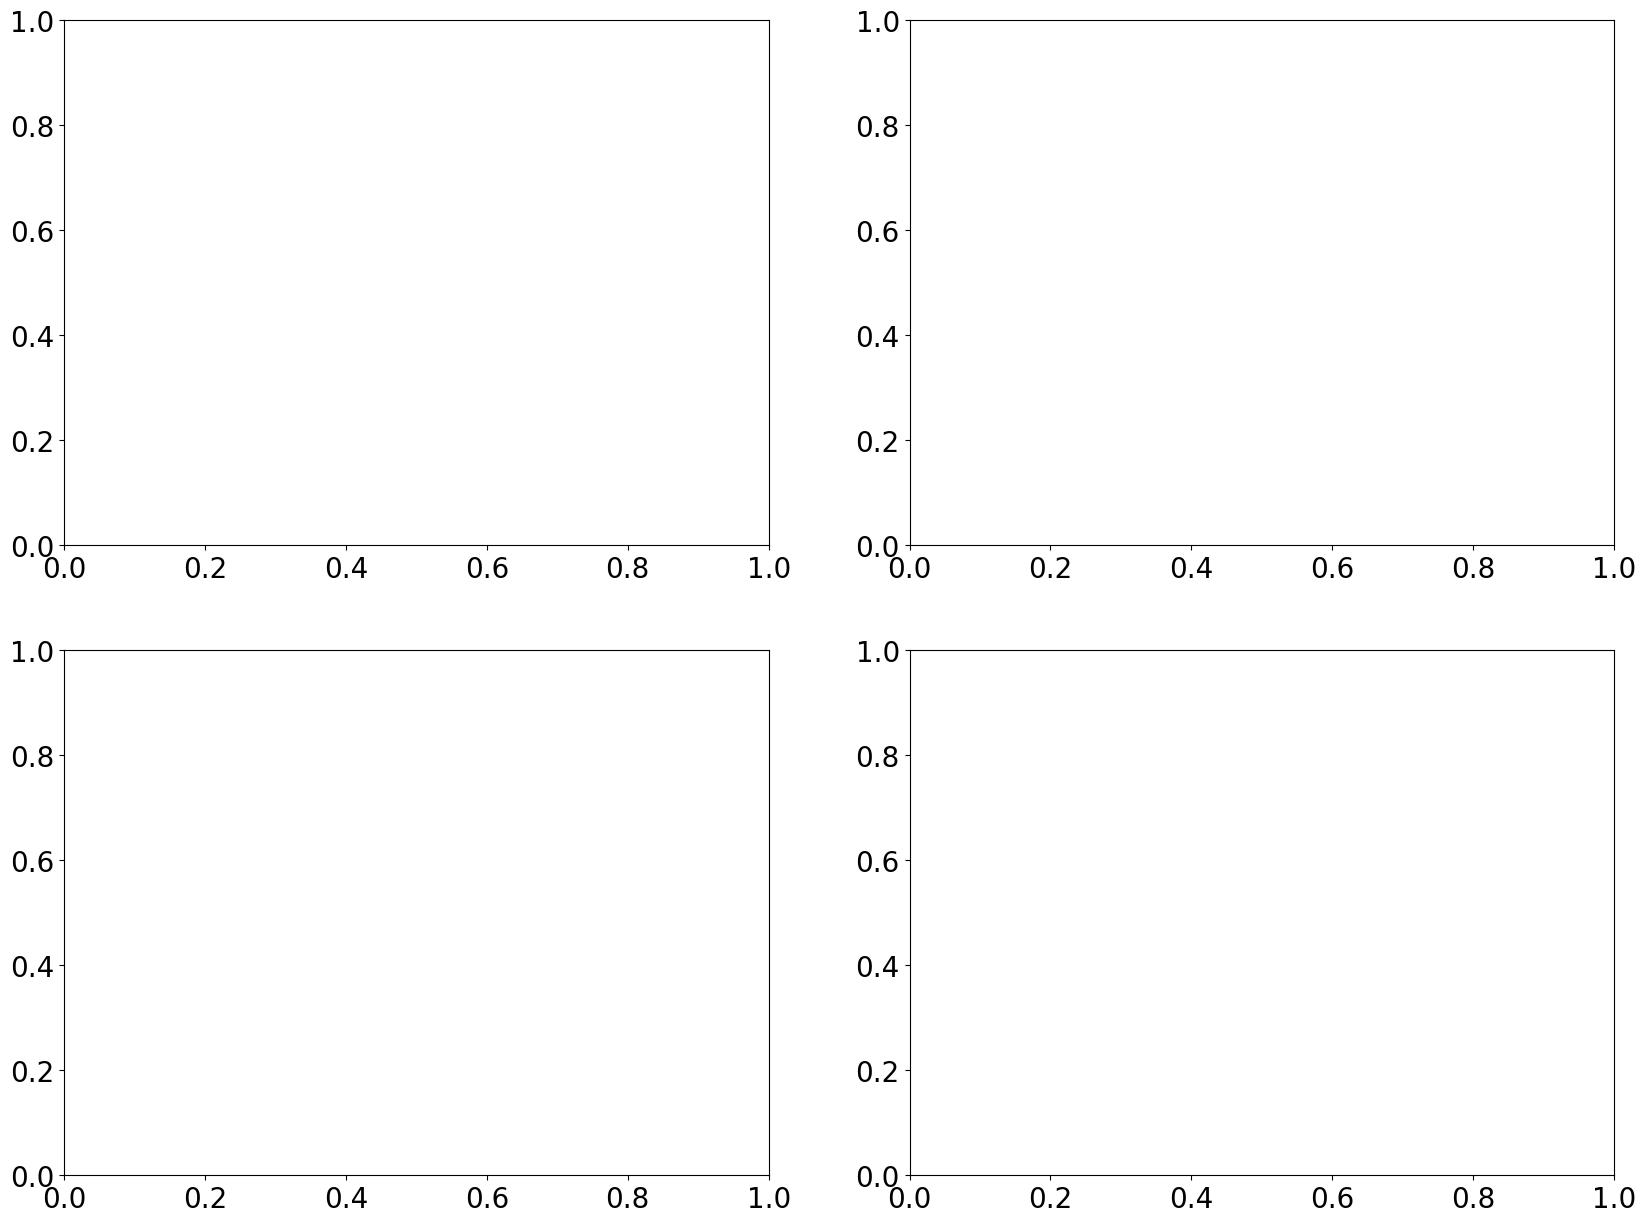

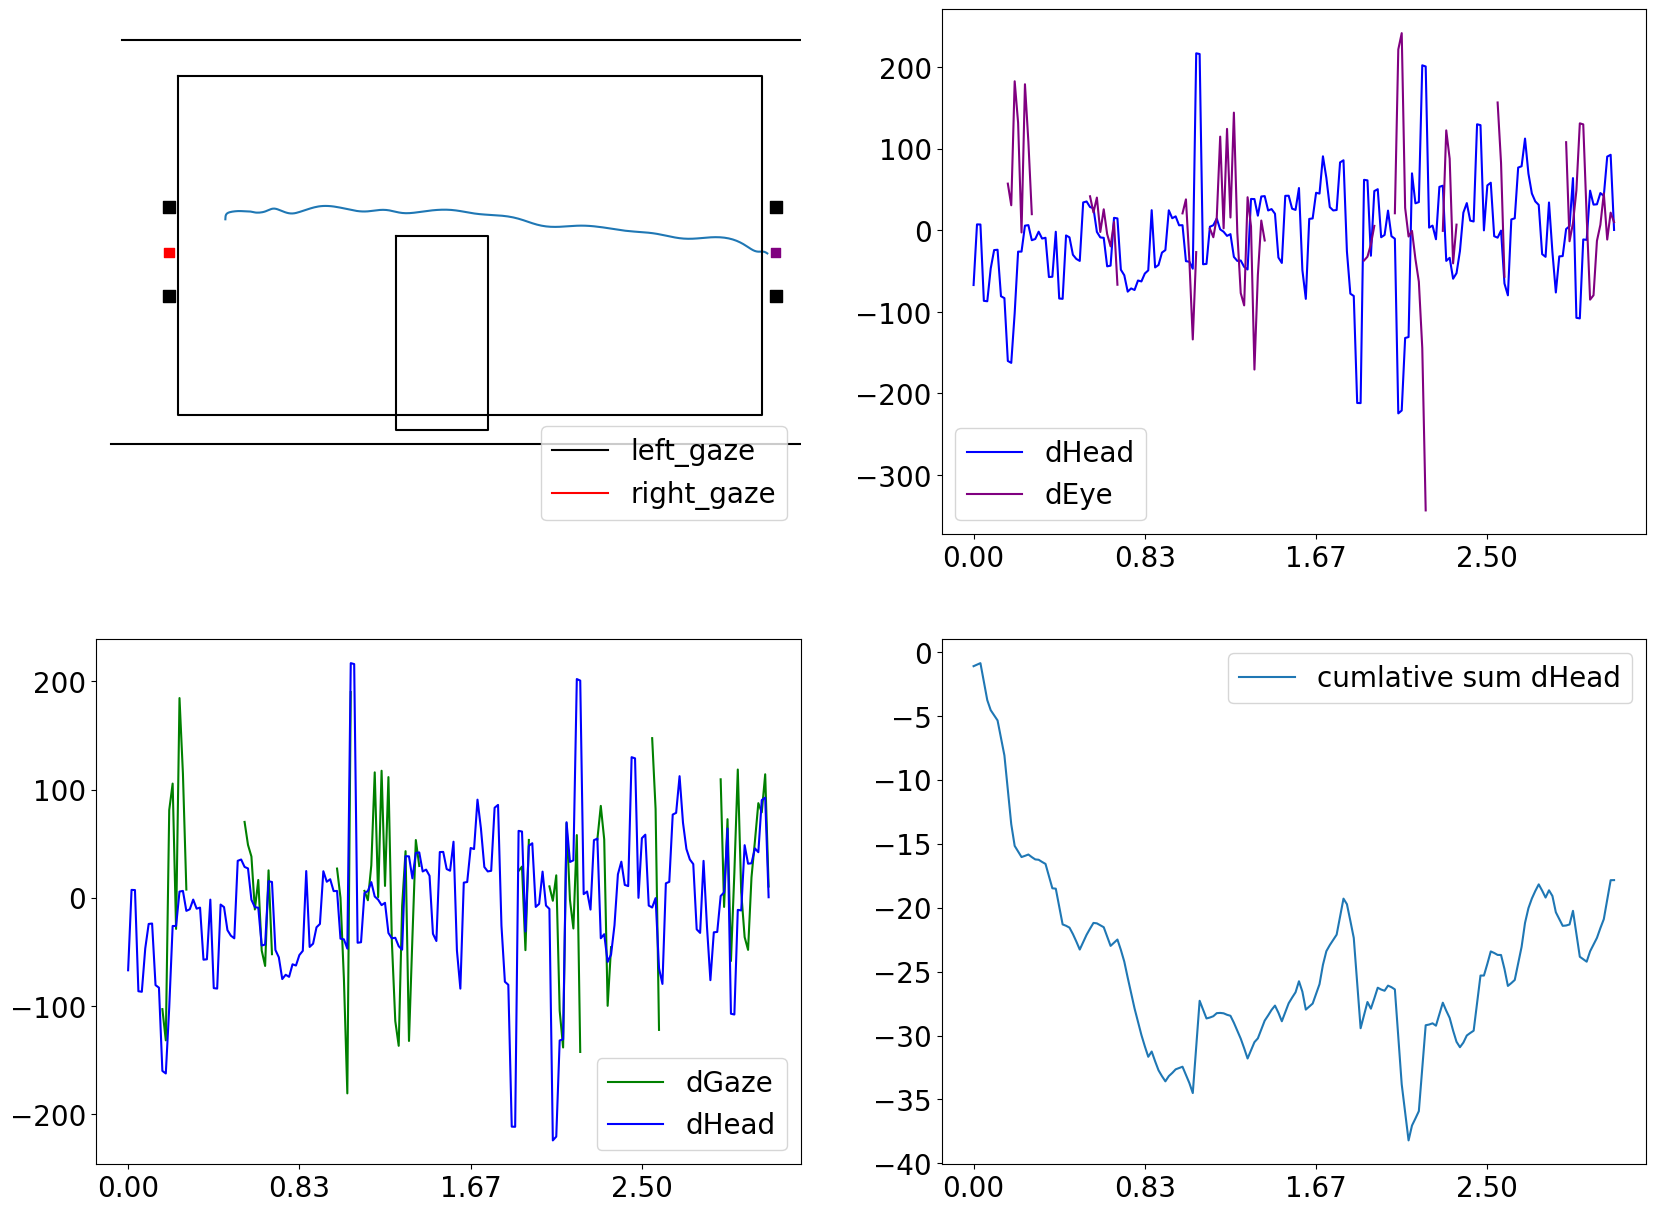

In [19]:
J731_051325_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\cluster_J731_051325_oa.h5")
J731_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_imu_eyecam_dict.npz")
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\051325\J731\oa_cam\051325_J731_control_Rig2_oa_cam_WORLDdeinter.avi"
]
gaze_shift_trials_figures_pdf(
    df =  J731_051325_df, eyeT=J731_051325_imu['eyeT'], dEye_dps=J731_051325_imu['dEye_dps'],dGaze=J731_051325_imu['dGaze'],dHead=J731_051325_imu['dHead'],gazeR_event=J731_051325_imu['gazeR_event'], gazeL_event=J731_051325_imu['gazeL_event'], OpenephysT0=J731_051325_imu['Openephys_time'][0],output_dir=r"\\goeppert\Vol2\mike\recordings\051325\J731\oa_cam",
    video_paths=video_paths, output_filename="051325_J731_gaze_new_criterian_analysis.pdf"  # Average ±2 frames around the target
)